# COVID-19 Data Analysis — Exploratory Data Analysis
**Author:** Marvis Obanor
**Date:** 17 June 2026
**Dataset:** COVID-19 Clean Complete Dataset (Kaggle)

## Introduction
COVID-19 was one of the most devastating global pandemics in modern history.
In this project, I perform an exploratory data analysis (EDA) on COVID-19 data
to answer the following questions:

- How did global COVID-19 cases grow over time?
- Which countries had the highest total confirmed cases?
- Which countries had the highest total deaths?
- What was the death rate across the top 10 affected countries?
- What was the recovery rate across the top 10 affected countries?

The dataset was sourced from Kaggle and contains daily COVID-19 statistics
across multiple countries from January 2020 onwards.

In [34]:
# Import the core libraries needed for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean background style for all charts
sns.set_style("whitegrid")

# Set a default figure size for all charts
plt.rcParams["figure.figsize"] = (12, 5)

In [35]:
# Load the main time series dataset containing daily stats per country
df = pd.read_csv("covid_19_clean_complete.csv")

# Load the country level summary dataset from worldometer
country_df = pd.read_csv("worldometer_data.csv")

# Print the number of rows and columns to understand the size of the data
print(df.shape)


(49068, 10)


In [36]:
# Print all column names to understand what data is available
print(df.columns.tolist())

['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']


In [37]:
# Preview the first 5 rows of the dataset
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [38]:
# Calculate the percentage of missing values for each column
# This helps us decide how to handle them before analysis
missing = (df.isnull().sum() / len(df)) * 100

# Display only columns that have missing values, sorted from highest to lowest
print(missing[missing > 0].sort_values(ascending=False))

Province/State    70.114943
dtype: float64


In [39]:
# Convert the Date column from string to datetime format for proper time series analysis
df["Date"] = pd.to_datetime(df["Date"])

# Fill missing numeric values with 0 so calculations don't break
# Missing values here likely mean no cases were recorded, so 0 is appropriate
df[["Confirmed", "Deaths", "Recovered", "Active"]] = df[["Confirmed", "Deaths", "Recovered", "Active"]].fillna(0)

# Rename the country column to something shorter and easier to reference
df.rename(columns={"Country/Region": "Country"}, inplace=True)

In [40]:
# Confirm the shape of the cleaned dataset
print(df.shape)
df.head()

(49068, 10)


,Province/State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


# How did global COVID-19 confirmed cases grow over time ?

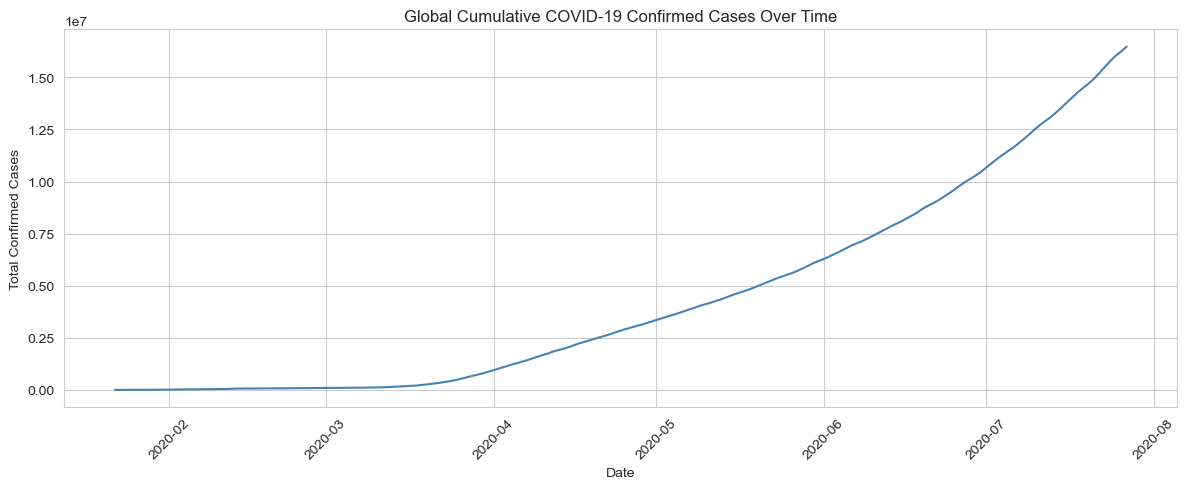

In [41]:
# Group all countries by date and sum confirmed cases to get a global daily total
global_cases = df.groupby("Date")["Confirmed"].sum().reset_index()

# Line chart is best for showing trends over time
plt.plot(global_cases["Date"], global_cases["Confirmed"], color="steelblue", linewidth=1.5)
plt.title("Global Cumulative COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Confirmed Cases")
plt.xticks(rotation=45)  # Rotate date labels so they don't overlap
plt.tight_layout()       # Automatically adjust layout to prevent clipping
plt.show()

Global COVID-19 confirmed cases grew slowly at the start of 2020 before rising sharply in mid to late 2020 as the virus spread across continents. The curve continued to climb steeply into 2021, reflecting how quickly the virus overwhelmed global health systems. The consistent upward trend highlights how difficult it was to contain the virus on a global scale despite various lockdowns and restrictions.

# Which countries had the highest total confirmed COVID-19 cases ?

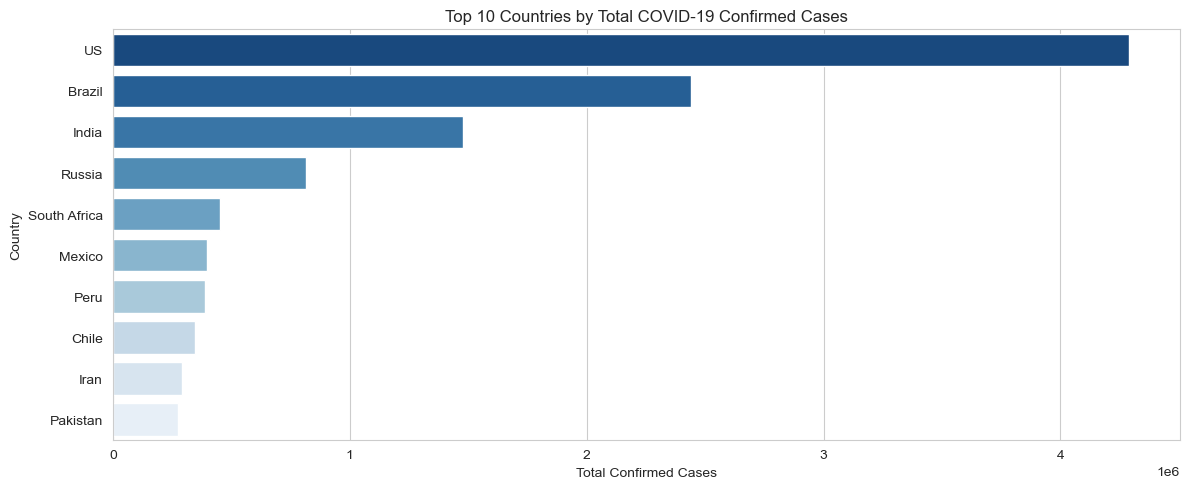

In [42]:
# Get the last recorded row for each country which contains their cumulative totals
latest = df.groupby("Country").last().reset_index()

# Sort by confirmed cases and select the top 10 countries
top_cases = latest.nlargest(10, "Confirmed")[["Country", "Confirmed"]]

# Horizontal bar chart
sns.barplot(
    data=top_cases,
    x="Confirmed",
    y="Country",
    hue="Country",
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 Countries by Total COVID-19 Confirmed Cases")
plt.xlabel("Total Confirmed Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

The United States recorded the highest number of confirmed COVID-19 cases by a significant margin, followed by India and Brazil. This reflects both the population size of these countries and the challenges they faced in controlling the spread of the virus. Notably, all top 10 countries are either highly populated or densely connected nations, which likely accelerated transmission.

# Which countries recorded the highest number of COVID-19 deaths ?

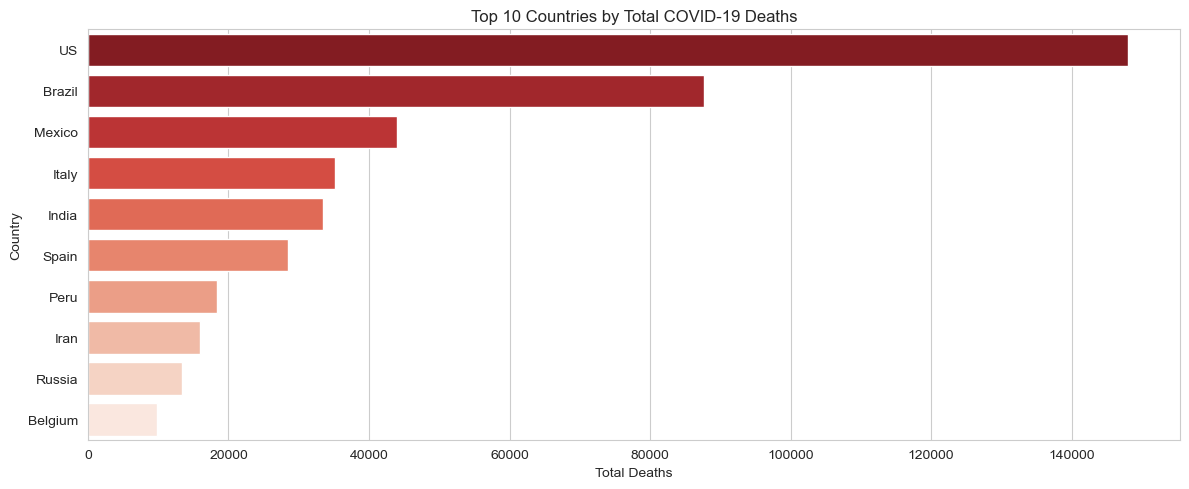

In [43]:
# Sort countries by total deaths and select the top 10
top_deaths = latest.nlargest(10, "Deaths")[["Country", "Deaths"]]

# Use red palette to visually distinguish deaths from cases
sns.barplot(
    data=top_deaths,
    x="Deaths",
    y="Country",
    hue="Country",
    palette="Reds_r",
    legend=False
)

plt.title("Top 10 Countries by Total COVID-19 Deaths")
plt.xlabel("Total Deaths")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

The United States also led in total COVID-19 deaths, followed by Brazil and Mexico. The high death tolls in these countries point to a combination of factors including healthcare capacity, speed of response, and population vulnerability. It is worth noting that some countries with high case counts do not necessarily appear in the top 10 for deaths, suggesting differences in healthcare quality and reporting standards.

# Which of the top 10 most affected countries had the highest death rate ?

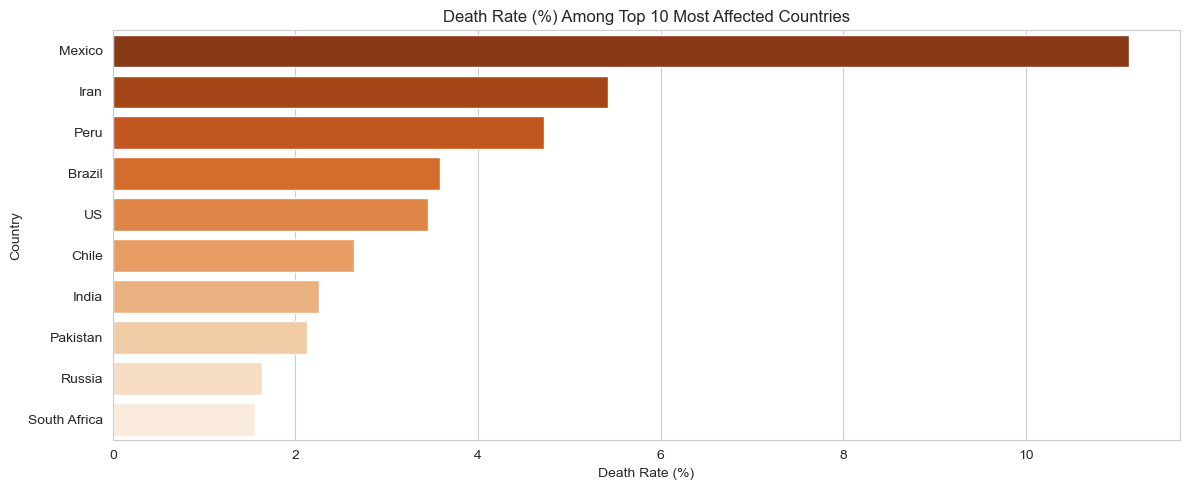

In [44]:
# Filter the dataset to only include the top 10 most affected countries
top_cases_list = top_cases["Country"].tolist()
death_rate_df = latest[latest["Country"].isin(top_cases_list)].copy()

# Calculate death rate as a percentage of total confirmed cases
death_rate_df["Death_Rate"] = (
    death_rate_df["Deaths"] / death_rate_df["Confirmed"]
) * 100

# Sort from highest to lowest death rate
death_rate_df = death_rate_df.sort_values("Death_Rate", ascending=False)

sns.barplot(
    data=death_rate_df,
    x="Death_Rate",
    y="Country",
    hue="Country",
    palette="Oranges_r",
    legend=False
)

plt.title("Death Rate (%) Among Top 10 Most Affected Countries")
plt.xlabel("Death Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Among the top 10 most affected countries, Mexico recorded one of the highest death rates as a percentage of confirmed cases. This could reflect underreporting of actual cases, meaning the true number of infections was likely much higher than officially recorded. A high death rate does not always mean more people died but can indicate that only the most severe cases were being tested and counted.

# Which of the top 10 most affected countries had the highest recovery rate ?

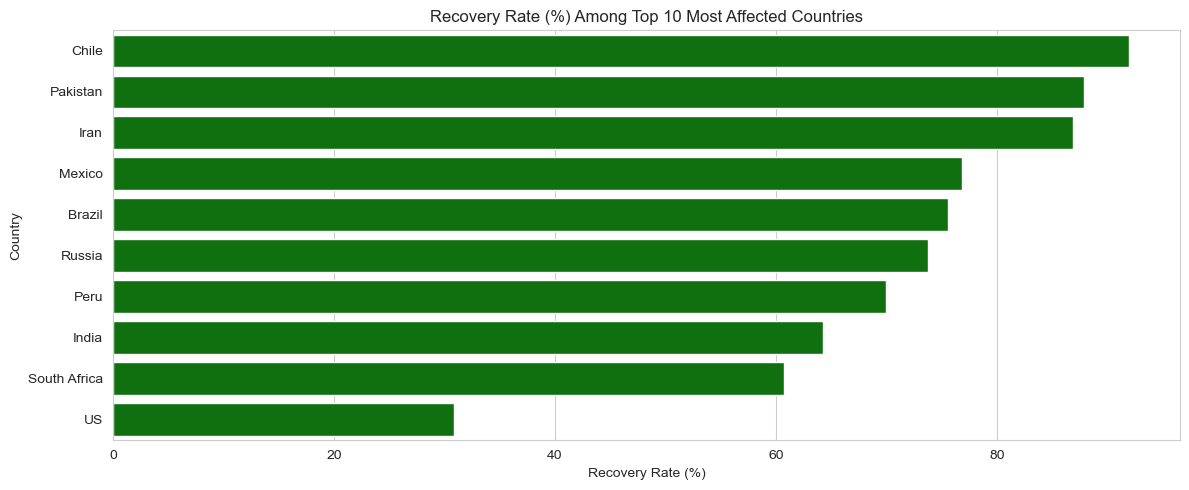

In [45]:
# Filter the dataset to only include the top 10 most affected countries
recovery_df = latest[latest["Country"].isin(top_cases_list)].copy()

# Calculate recovery rate as a percentage of total confirmed cases
recovery_df["Recovery_Rate"] = (
    recovery_df["Recovered"] / recovery_df["Confirmed"]
) * 100

# Sort from highest to lowest recovery rate
recovery_df = recovery_df.sort_values("Recovery_Rate", ascending=False)

sns.barplot(
    data=recovery_df,
    x="Recovery_Rate",
    y="Country",
    color="green"
)

plt.title("Recovery Rate (%) Among Top 10 Most Affected Countries")
plt.xlabel("Recovery Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

The majority of the top 10 most affected countries recorded recovery rates above 90%, which is an encouraging sign of the resilience of healthcare systems globally. India and Brazil showed particularly high recovery rates despite their large case numbers, suggesting effective treatment protocols were in place. Countries with lower recovery rates may reflect differences in how recovered cases were tracked and reported rather than actual treatment outcomes.

In [46]:
# Final summary of key insights from the analysis
print("=== PROJECT SUMMARY ===")
print(f"Total Records Analyzed: {df.shape[0]}")                    # shape[0] returns number of rows
print(f"Countries Covered: {df['Country'].nunique()}")             # nunique() counts unique countries
print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")  # min and max dates
print(f"Country with Most Cases: {top_cases.iloc[0]['Country']}")             # iloc[0] gets the top row
print(f"Country with Most Deaths: {top_deaths.iloc[0]['Country']}")
print(f"Highest Death Rate: {death_rate_df.iloc[0]['Country']} ({death_rate_df.iloc[0]['Death_Rate']:.2f}%)")    # :.2f formats to 2 decimal places
print(f"Highest Recovery Rate: {recovery_df.iloc[0]['Country']} ({recovery_df.iloc[0]['Recovery_Rate']:.2f}%)")

=== PROJECT SUMMARY ===
Total Records Analyzed: 49068
Countries Covered: 187
Date Range: 2020-01-22 to 2020-07-27
Country with Most Cases: US
Country with Most Deaths: US
Highest Death Rate: Mexico (11.13%)
Highest Recovery Rate: Chile (91.96%)
